A convenient way to download the issues is via the requests library, which is the standard way for making HTTP requests in Python. You can install the library by running:

# Getting the data

In [2]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


Once the library is installed, you can make GET requests to the "Issues" endpoint by invoking the requests.get() function. For example, you can run the following command to retrieve the first issue on the first page:

In [5]:
import requests

url = "https://api.github.com/repos/huggingface/datasets/issues?page=1&per_page=1"
response = requests.get(url)

The response object contains a lot of useful information about the request, including the HTTP status code:

In [6]:
response

<Response [200]>

In [7]:
response.status_code

200

where a 200 status means the request was successful (you can find a list of possible HTTP status codes <https://en.wikipedia.org/wiki/List_of_HTTP_status_codes> ) .we know our issues are in JSON format, let’s inspect the payload as follows:

In [10]:
response.json()

[{'url': 'https://api.github.com/repos/huggingface/datasets/issues/8055',
  'repository_url': 'https://api.github.com/repos/huggingface/datasets',
  'labels_url': 'https://api.github.com/repos/huggingface/datasets/issues/8055/labels{/name}',
  'comments_url': 'https://api.github.com/repos/huggingface/datasets/issues/8055/comments',
  'events_url': 'https://api.github.com/repos/huggingface/datasets/issues/8055/events',
  'html_url': 'https://github.com/huggingface/datasets/pull/8055',
  'id': 4042507479,
  'node_id': 'PR_kwDODunzps7I6knM',
  'number': 8055,
  'title': 'feat: add 3D mesh support and MeshFolder builder',
  'user': {'login': 'Vinay-Umrethe',
   'id': 175500353,
   'node_id': 'U_kgDOCnXsQQ',
   'avatar_url': 'https://avatars.githubusercontent.com/u/175500353?v=4',
   'gravatar_id': '',
   'url': 'https://api.github.com/users/Vinay-Umrethe',
   'html_url': 'https://github.com/Vinay-Umrethe',
   'followers_url': 'https://api.github.com/users/Vinay-Umrethe/followers',
   'foll

Whoa, that’s a lot of information! We can see useful fields like title, body, and number that describe the issue, as well as information about the GitHub user who opened the issue.

As described in the GitHub documentation, unauthenticated requests are limited to 60 requests per hour. Although you can increase the per_page query parameter to reduce the number of requests you make, you will still hit the rate limit on any repository that has more than a few thousand issues. So instead, you should follow GitHub’s instructions on creating a personal access token so that you can boost the rate limit to 5,000 requests per hour. Once you have your token, you can include it as part of the request header:

In [ ]:
GITHUB_TOKEN = xxx  # Copy your GitHub token here
headers = {"Authorization": f"token {GITHUB_TOKEN}"}

Now that we have our access token, let’s create a function that can download all the issues from a GitHub repository:

In [13]:
import time
import math
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm


def fetch_issues(
    owner="huggingface",
    repo="datasets",
    num_issues=10_000,
    rate_limit=5_000,
    issues_path=Path("."),
):
    if not issues_path.is_dir():
        issues_path.mkdir(exist_ok=True)

    batch = []
    all_issues = []
    per_page = 100  # Number of issues to return per page
    num_pages = math.ceil(num_issues / per_page)
    base_url = "https://api.github.com/repos"

    for page in tqdm(range(num_pages)):
        # Query with state=all to get both open and closed issues
        query = f"issues?page={page}&per_page={per_page}&state=all"
        issues = requests.get(f"{base_url}/{owner}/{repo}/{query}", headers=headers)
        batch.extend(issues.json())

        if len(batch) > rate_limit and len(all_issues) < num_issues:
            all_issues.extend(batch)
            batch = []  # Flush batch for next time period
            print(f"Reached GitHub rate limit. Sleeping for one hour ...")
            time.sleep(60 * 60 + 1)

    all_issues.extend(batch)
    df = pd.DataFrame.from_records(all_issues)
    df.to_json(f"{issues_path}/{repo}-issues.jsonl", orient="records", lines=True)
    print(
        f"Downloaded all the issues for {repo}! Dataset stored at {issues_path}/{repo}-issues.jsonl"
    )

Now when we call fetch_issues() it will download all the issues in batches to avoid exceeding GitHub’s limit on the number of requests per hour; the result will be stored in a repository_name-issues.jsonl file, where each line is a JSON object the represents an issue.

In [ ]:
# Depending on your internet connection, this can take several minutes to run...
fetch_issues()

In [ ]:
issues_dataset = load_dataset("json", data_files="datasets-issues.jsonl", split="train")
issues_dataset

# Cleaning up the data

The above snippet from GitHub’s documentation tells us that the pull_request column can be used to differentiate between issues and pull requests. Let’s look at a random sample to see what the difference is. As we did in section 3, we’ll chain Dataset.shuffle() and Dataset.select() to create a random sample and then zip the html_url and pull_request columns so we can compare the various URLs:

In [ ]:
sample = issues_dataset.shuffle(seed=666).select(range(3))

# Print out the URL and pull request entries
for url, pr in zip(sample["html_url"], sample["pull_request"]):
    print(f">> URL: {url}")
    print(f">> Pull request: {pr}\n")

Here we can see that each pull request is associated with various URLs, while ordinary issues have a None entry. We can use this distinction to create a new is_pull_request column that checks whether the pull_request field is None or not:

In [ ]:
issues_dataset = issues_dataset.map(
    lambda x: {"is_pull_request": False if x["pull_request"] is None else True}
)


Although we could proceed to further clean up the dataset by dropping or renaming some columns, it is generally a good practice to keep the dataset as “raw” as possible at this stage so that it can be easily used in multiple applications.

# Augmenting the dataset (Add Comment With Issue)

As shown in the following screenshot, the comments associated with an issue or pull request provide a rich source of information, especially if we’re interested in building a search engine to answer user queries about the library.



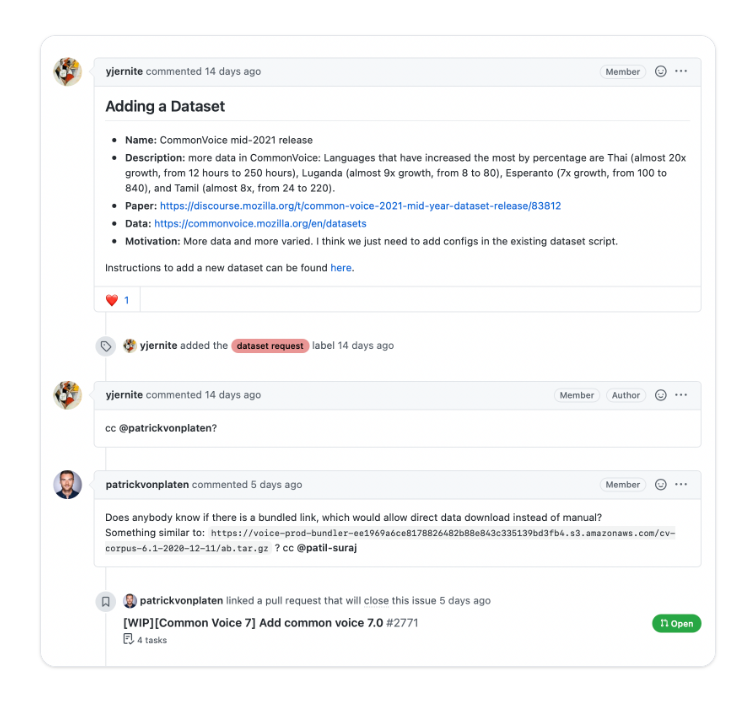

The GitHub REST API provides a Comments endpoint that returns all the comments associated with an issue number. Let’s test the endpoint to see what it returns:

In [ ]:
issue_number = 2792
url = f"https://api.github.com/repos/huggingface/datasets/issues/{issue_number}/comments"
response = requests.get(url, headers=headers)
response.json()

We can see that the comment is stored in the body field, so let’s write a simple function that returns all the comments associated with an issue by picking out the body contents for each element in response.json():

In [ ]:
def get_comments(issue_number):
    url = f"https://api.github.com/repos/huggingface/datasets/issues/{issue_number}/comments"
    response = requests.get(url, headers=headers)
    return [r["body"] for r in response.json()]


# Test our function works as expected
get_comments(2792)

This looks good, so let’s use Dataset.map() to add a new comments column to each issue in our dataset:

In [ ]:
# Depending on your internet connection, this can take a few minutes...
issues_with_comments_dataset = issues_dataset.map(
    lambda x: {"comments": get_comments(x["number"])}
)

The final step is to push our dataset to the Hub. Let’s take a look at how we can do that.

# Uploading the dataset to the Hugging Face Hub

Now that we have our augmented dataset, it’s time to push it to the Hub so we can share it with the community! Uploading a dataset is very simple: just like models and tokenizers from Transformers, we can use a push_to_hub() method to push a dataset. To do that we need an authentication token, which can be obtained by first logging into the Hugging Face Hub with the notebook_login() function:

In [18]:
from huggingface_hub import notebook_login

notebook_login()

 we can upload our dataset by running:

In [ ]:
issues_with_comments_dataset.push_to_hub("github-issues")

# Creating a dataset card

Well-documented datasets are more likely to be useful to others (including your future self!), as they provide the context to enable users to decide whether the dataset is relevant to their task and to evaluate any potential biases in or risks associated with using the dataset.

On the Hugging Face Hub, this information is stored in each dataset repository’s README.md file. There are two main steps you should take before creating this file:

1. Use the datasets-tagging application to create metadata tags in YAML format. These tags are used for a variety of search features on the Hugging Face Hub and ensure your dataset can be easily found by members of the community. Since we have created a custom dataset here, you’ll need to clone the datasets-tagging repository and run the application locally. Here’s what the interface looks like:

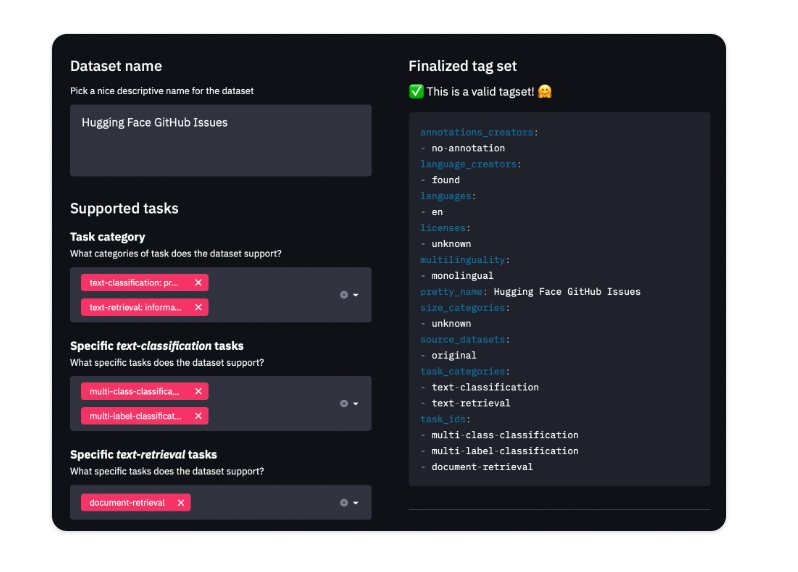

2. Read the Datasets guide on creating informative dataset cards and use it as a template.
You can create the README.md file directly on the Hub, and you can find a template dataset card in the lewtun/github-issues dataset repository. A screenshot of the filled-out dataset card is shown below.

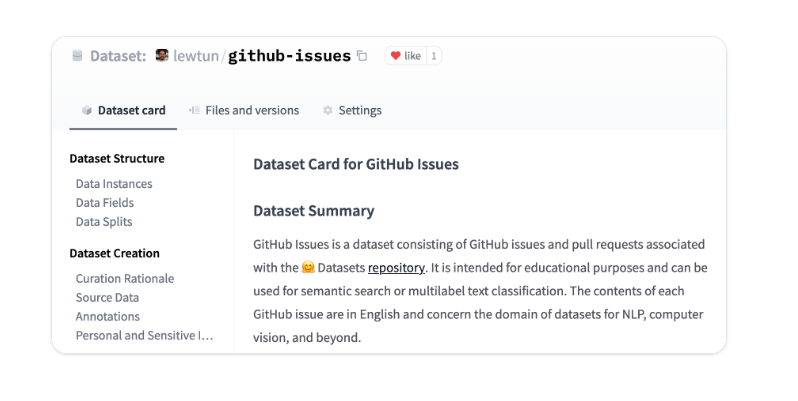